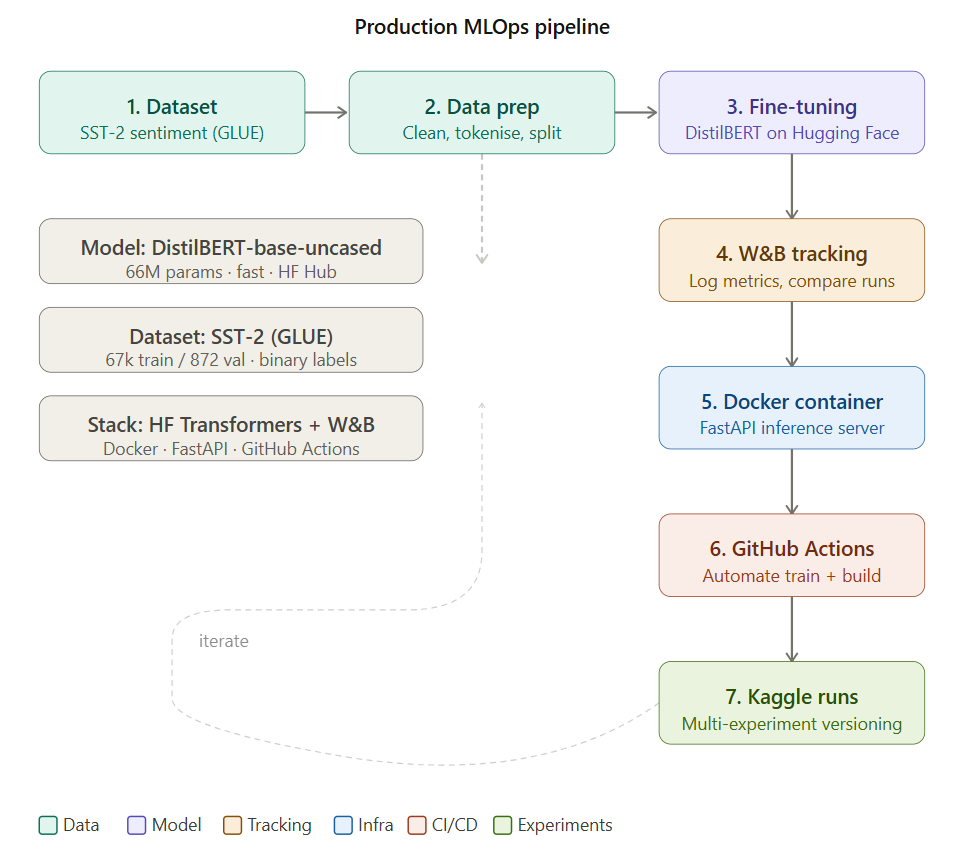

Dataset: SST-2 (Stanford Sentiment Treebank, binary) from the GLUE benchmark — 67k training sentences, 872 validation, two labels (positive/negative). Small enough to fine-tune in under an hour on a free GPU.
Model: distilbert-base-uncased from Hugging Face — 66M parameters, 40% smaller than BERT-base, retains 97% of BERT's accuracy. Perfect for a teaching pipeline.
Task: Sentence-level sentiment classification.

In [2]:
import torch
import transformers
import datasets
import wandb
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("wandb:", wandb.__version__)

torch: 2.10.0+cu128
transformers: 5.0.0
datasets: 4.8.5
wandb: 0.25.1


In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [4]:
# ── CELL 2 ── Load secrets (Kaggle Secrets — never hard-code tokens) ──────────
from kaggle_secrets import UserSecretsClient
import os
import wandb
from huggingface_hub import login

secrets = UserSecretsClient()

os.environ["WANDB_API_KEY"] = secrets.get_secret("WANDB_API_KEY")
HF_TOKEN = secrets.get_secret("HF_TOKEN")

login(token=HF_TOKEN)   # authenticate with Hugging Face Hub
wandb.login()           # authenticate with W&B (uses env var set above)

print("Secrets loaded ✓")


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: g25ait2096 (g25ait2096-iitj) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Secrets loaded ✓


In [5]:
import wandb

run = wandb.init(
    project="test-project",
    name="test-run"
)

wandb.log({"accuracy": 0.95})
run.finish()

accuracy,▁
accuracy,0.95


In [13]:
# ── CELL 3 ── Imports ─────────────────────────────────────────────────────────
import json
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset, DatasetDict, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import accuracy_score, f1_score

In [14]:

# ── CELL 4 ── Configuration V2 ───────────────────────────────────────────────
VERSION       = "v2"
MODEL_NAME    = "distilbert-base-uncased"
NUM_EPOCHS    = 5
BATCH_SIZE    = 32
LEARNING_RATE = 2e-5
TRAIN_SIZE    = 20_000
VAL_SIZE      = 872
SEED          = 42

id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}
print(f"Version: {VERSION} | Epochs: {NUM_EPOCHS} | LR: {LEARNING_RATE} | Batch: {BATCH_SIZE}")



Version: v2 | Epochs: 5 | LR: 2e-05 | Batch: 32


In [15]:
# ── CELL 5+6 ── Data Preparation + Tokenisation ───────────────────────────────
import re
from datasets import Dataset

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^\x20-\x7E]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Load dataset
raw = load_dataset("stanfordnlp/sst2")

# Prepare dataframes
train_df = raw["train"].to_pandas()
val_df   = raw["validation"].to_pandas()

train_df["sentence"] = train_df["sentence"].map(clean_text)
val_df["sentence"]   = val_df["sentence"].map(clean_text)

train_df = train_df[train_df["sentence"].str.len() > 0].drop_duplicates("sentence")
val_df   = val_df[val_df["sentence"].str.len() > 0].drop_duplicates("sentence")

train_df = train_df.sample(n=min(TRAIN_SIZE, len(train_df)), random_state=SEED).reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")

# Tokenise
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenise(batch):
    return tokenizer(
        batch["sentence"],
        truncation=True,
        max_length=256,
        padding=False,
    )

train_ds = Dataset.from_pandas(train_df[["sentence", "label"]])
val_ds   = Dataset.from_pandas(val_df[["sentence", "label"]])

train_tok = train_ds.map(tokenise, batched=True)
val_tok   = val_ds.map(tokenise,   batched=True)

train_tok = train_tok.rename_column("label", "labels")
val_tok   = val_tok.rename_column("label", "labels")

train_tok = train_tok.remove_columns(["sentence"])
val_tok   = val_tok.remove_columns(["sentence"])

train_tok.set_format("torch")
val_tok.set_format("torch")

collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Tokenisation done ✓")
print("Train columns:", train_tok.column_names)
print("Val columns:  ", val_tok.column_names)
print("Sample:", train_tok[0])

Train: 20000 | Val: 872


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Tokenisation done ✓
Train columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Val columns:   ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Sample: {'labels': tensor(1), 'input_ids': tensor([  101,  2720,  1012,  2154,  1011,  4572, 11950,  2015,  2007,  6506,
         3170,  2373,   102]), 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


DATASET OVERVIEW
Training rows   : 67,349
Validation rows : 872
Columns         : ['idx', 'sentence', 'label']

--- Data Types ---
idx          int32
sentence    object
label        int64
dtype: object

--- Missing Values (Train) ---
idx         0
sentence    0
label       0
dtype: int64

--- Missing Values (Val) ---
idx         0
sentence    0
label       0
dtype: int64

--- Sample Rows ---
                                                                                                                                                sentence  label
0                                                                                                           hide new secretions from the parental units       0
1                                                                                                                   contains no wit , only labored gags       0
2                                                              that loves its characters and communicates something rather be

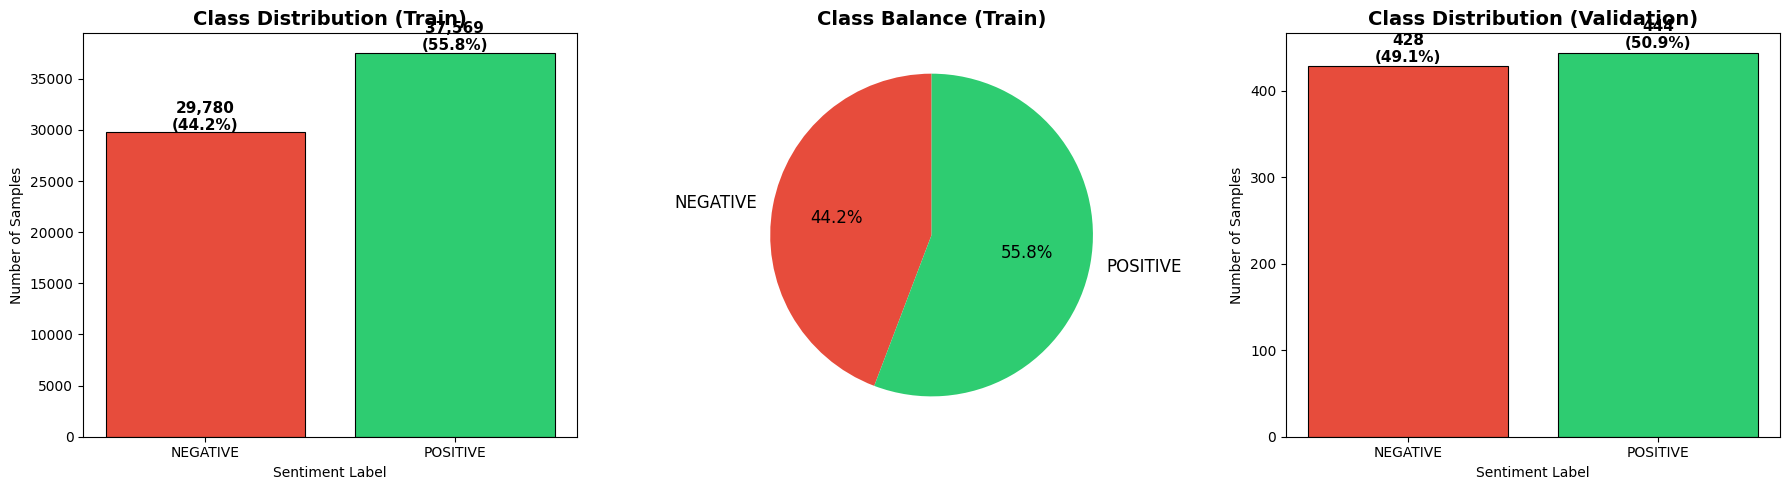

Plot 1 saved ✓


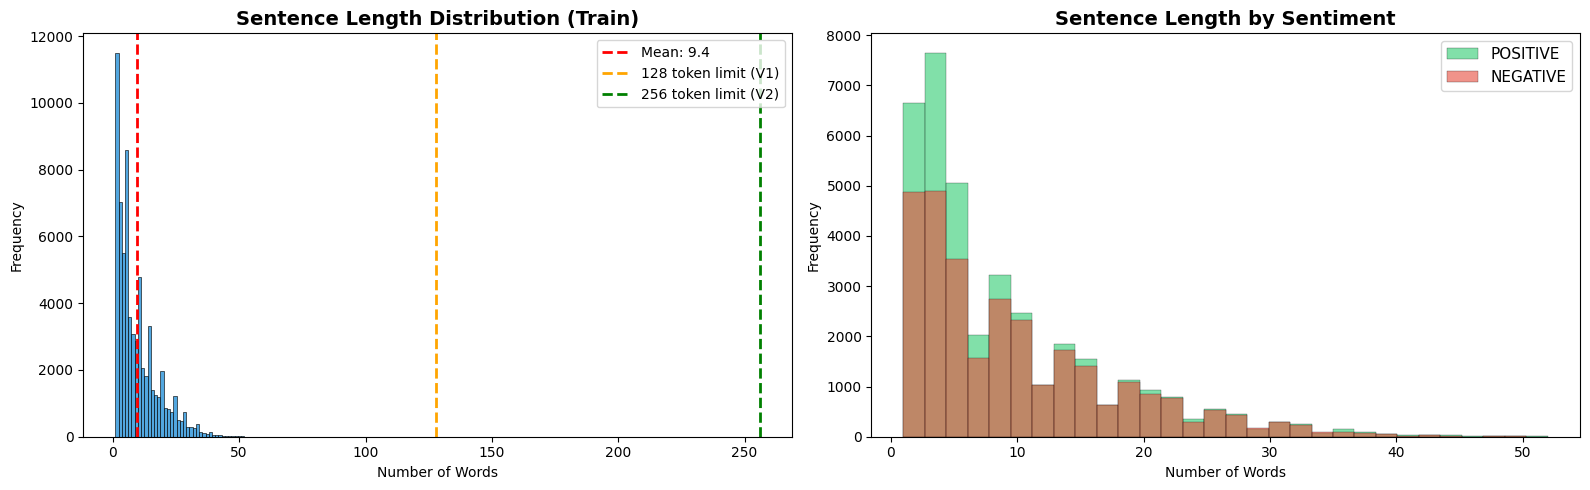

Plot 2 saved ✓


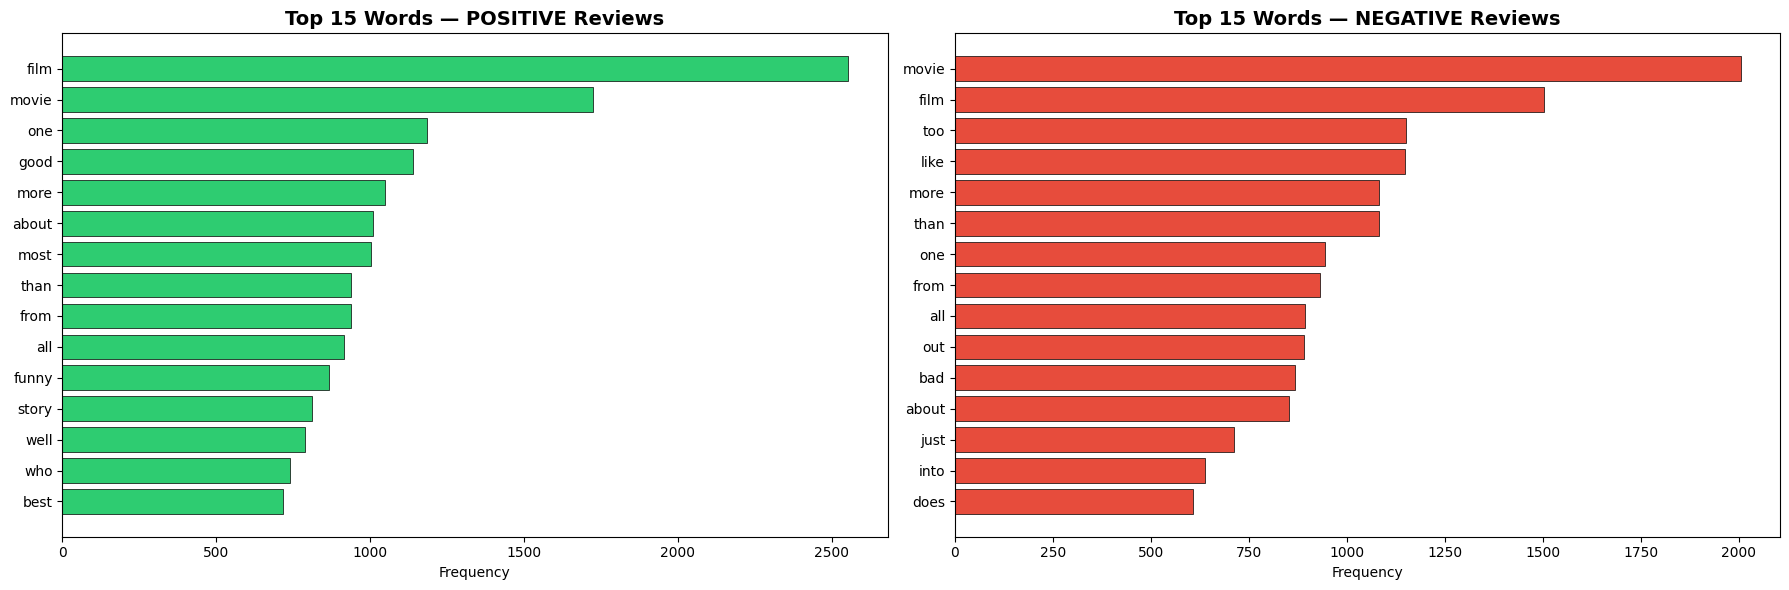

Plot 3 saved ✓

EDA COMPLETE


In [16]:
# ── EDA — Exploratory Data Analysis on SST-2 ─────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Load raw dataset
raw = load_dataset("stanfordnlp/sst2")
train_df = raw["train"].to_pandas()
val_df   = raw["validation"].to_pandas()

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Training rows   : {len(train_df):,}")
print(f"Validation rows : {len(val_df):,}")
print(f"Columns         : {train_df.columns.tolist()}")

print("\n--- Data Types ---")
print(train_df.dtypes)

print("\n--- Missing Values (Train) ---")
print(train_df.isnull().sum())

print("\n--- Missing Values (Val) ---")
print(val_df.isnull().sum())

print("\n--- Sample Rows ---")
print(train_df[["sentence", "label"]].head(10).to_string())

print("\n--- Class Distribution (Train) ---")
dist = train_df["label"].value_counts()
print(f"POSITIVE (1) : {dist[1]:,} rows ({dist[1]/len(train_df)*100:.1f}%)")
print(f"NEGATIVE (0) : {dist[0]:,} rows ({dist[0]/len(train_df)*100:.1f}%)")

print("\n--- Class Distribution (Val) ---")
val_dist = val_df["label"].value_counts()
print(f"POSITIVE (1) : {val_dist[1]:,} rows ({val_dist[1]/len(val_df)*100:.1f}%)")
print(f"NEGATIVE (0) : {val_dist[0]:,} rows ({val_dist[0]/len(val_df)*100:.1f}%)")

# Sentence length analysis
train_df["length"] = train_df["sentence"].str.split().str.len()
val_df["length"]   = val_df["sentence"].str.split().str.len()

print("\n--- Sentence Length Statistics (words) ---")
print(train_df["length"].describe().round(2))
print(f"\nMax length  : {train_df['length'].max()} words")
print(f"Min length  : {train_df['length'].min()} words")
print(f"Mean length : {train_df['length'].mean():.1f} words")
print(f"Sentences > 128 tokens : {(train_df['length'] > 128).sum()} ({(train_df['length'] > 128).mean()*100:.1f}%)")
print(f"Sentences > 256 tokens : {(train_df['length'] > 256).sum()} ({(train_df['length'] > 256).mean()*100:.1f}%)")

# ── Plot 1 — Class Distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart
labels_map = {0: "NEGATIVE", 1: "POSITIVE"}
colors     = ["#E74C3C", "#2ECC71"]
axes[0].bar(
    [labels_map[0], labels_map[1]],
    [dist[0], dist[1]],
    color=colors, edgecolor="black", linewidth=0.8
)
axes[0].set_title("Class Distribution (Train)", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Number of Samples")
axes[0].set_xlabel("Sentiment Label")
for i, v in enumerate([dist[0], dist[1]]):
    axes[0].text(i, v + 200, f"{v:,}\n({v/len(train_df)*100:.1f}%)",
                 ha="center", fontsize=11, fontweight="bold")

# Pie chart
axes[1].pie(
    [dist[0], dist[1]],
    labels=["NEGATIVE", "POSITIVE"],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 12}
)
axes[1].set_title("Class Balance (Train)", fontsize=14, fontweight="bold")

# Val class distribution
axes[2].bar(
    [labels_map[0], labels_map[1]],
    [val_dist[0], val_dist[1]],
    color=colors, edgecolor="black", linewidth=0.8
)
axes[2].set_title("Class Distribution (Validation)", fontsize=14, fontweight="bold")
axes[2].set_ylabel("Number of Samples")
axes[2].set_xlabel("Sentiment Label")
for i, v in enumerate([val_dist[0], val_dist[1]]):
    axes[2].text(i, v + 5, f"{v:,}\n({v/len(val_df)*100:.1f}%)",
                 ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 1 saved ✓")

# ── Plot 2 — Sentence Length Distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(train_df["length"], bins=40, color="#3498DB",
             edgecolor="black", linewidth=0.5, alpha=0.85)
axes[0].axvline(train_df["length"].mean(), color="red",
                linestyle="--", linewidth=2, label=f'Mean: {train_df["length"].mean():.1f}')
axes[0].axvline(128, color="orange", linestyle="--",
                linewidth=2, label="128 token limit (V1)")
axes[0].axvline(256, color="green", linestyle="--",
                linewidth=2, label="256 token limit (V2)")
axes[0].set_title("Sentence Length Distribution (Train)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Number of Words")
axes[0].set_ylabel("Frequency")
axes[0].legend(fontsize=10)

# Length by label
train_df["sentiment"] = train_df["label"].map({0: "NEGATIVE", 1: "POSITIVE"})
for label, color in zip(["POSITIVE", "NEGATIVE"], ["#2ECC71", "#E74C3C"]):
    subset = train_df[train_df["sentiment"] == label]["length"]
    axes[1].hist(subset, bins=30, alpha=0.6, label=label,
                 color=color, edgecolor="black", linewidth=0.3)
axes[1].set_title("Sentence Length by Sentiment", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Number of Words")
axes[1].set_ylabel("Frequency")
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig("sentence_length.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 2 saved ✓")

# ── Plot 3 — Top words per class ──────────────────────────────────────────────
from collections import Counter
import re

stopwords = {"the","a","an","is","it","of","and","to","in","that","this",
             "was","as","its","but","with","for","are","on","be","at","by",
             "have","had","has","not","he","she","his","her","they","we","you"}

def top_words(df, label, n=15):
    text = " ".join(df[df["label"] == label]["sentence"].tolist()).lower()
    words = re.findall(r"\b[a-z]{3,}\b", text)
    words = [w for w in words if w not in stopwords]
    return Counter(words).most_common(n)

pos_words = top_words(train_df, 1)
neg_words = top_words(train_df, 0)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh([w for w, _ in pos_words[::-1]],
             [c for _, c in pos_words[::-1]],
             color="#2ECC71", edgecolor="black", linewidth=0.5)
axes[0].set_title("Top 15 Words — POSITIVE Reviews", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Frequency")

axes[1].barh([w for w, _ in neg_words[::-1]],
             [c for _, c in neg_words[::-1]],
             color="#E74C3C", edgecolor="black", linewidth=0.5)
axes[1].set_title("Top 15 Words — NEGATIVE Reviews", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.savefig("top_words.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 3 saved ✓")

print("\n" + "=" * 55)
print("EDA COMPLETE")
print("=" * 55)

In [17]:
# ── CELL 7 ── Load model ──────────────────────────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 66,955,010


In [18]:
# ── CELL 8 ── W&B run init ────────────────────────────────────────────────────
wandb.init(
    project="mlops-assignment3",
    name=f"run-{VERSION}",
    config={
        "model":         MODEL_NAME,
        "epochs":        NUM_EPOCHS,
        "batch_size":    BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "version":       VERSION,
        "platform":      "Kaggle",
        "train_size":    TRAIN_SIZE,
        "val_size":      VAL_SIZE,
    },
)
print(f"W&B run '{VERSION}' initialised ✓")

W&B run 'v2' initialised ✓


In [21]:
# ── CELL 9 ── Metrics function ────────────────────────────────────────────────
def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds, average="weighted"),
    }

In [22]:
# ── CELL 10 ── Training Arguments V2 ─────────────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = f"./results-{VERSION}",
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = 64,
    learning_rate               = LEARNING_RATE,
    warmup_ratio                = 0.15,
    weight_decay                = 0.02,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    report_to                   = "wandb",
    run_name                    = f"run-{VERSION}",
    seed                        = SEED,
    fp16                        = torch.cuda.is_available(),
    lr_scheduler_type           = "cosine",
    gradient_accumulation_steps = 2,
)
print("Training args ready ✓")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training args ready ✓


In [23]:
# ── CELL 11 ── Train ──────────────────────────────────────────────────────────
trainer = Trainer(
    model             = model,
    args              = training_args,
    train_dataset     = train_tok,
    eval_dataset      = val_tok,
    processing_class  = tokenizer,
    data_collator     = collator,
    compute_metrics   = compute_metrics,
)



In [24]:
# ── CELL 12 ── Evaluate & log final metrics ───────────────────────────────────
results = trainer.evaluate()
print("Final eval results:", results)

wandb.run.summary.update({
    "final_accuracy": results["eval_accuracy"],
    "final_f1":       results["eval_f1"],
    "final_loss":     results["eval_loss"],
})


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Final eval results: {'eval_loss': 1.38118577003479, 'eval_accuracy': 0.5091743119266054, 'eval_f1': 0.3435765873790469, 'eval_runtime': 2.0405, 'eval_samples_per_second': 427.349, 'eval_steps_per_second': 3.431}


In [25]:
print("Training logs:", trainer.state.log_history)

Training logs: [{'eval_loss': 1.38118577003479, 'eval_accuracy': 0.5091743119266054, 'eval_f1': 0.3435765873790469, 'eval_runtime': 2.0405, 'eval_samples_per_second': 427.349, 'eval_steps_per_second': 3.431, 'step': 0}]


In [26]:
# ── CELL 13 ── Push model to Hugging Face Hub (Task 5) ────────────────────────
HF_REPO = f"g25ait2096/distilbert-sst2-{VERSION}"   # ← replace username

model.push_to_hub(HF_REPO)
tokenizer.push_to_hub(HF_REPO)
print(f"Model pushed to: https://huggingface.co/{HF_REPO}")

# Log model URL to W&B run summary
wandb.run.summary["huggingface_model"] = f"https://huggingface.co/{HF_REPO}"

wandb.finish()
print("W&B run finished ✓")

README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Model pushed to: https://huggingface.co/g25ait2096/distilbert-sst2-v2


eval/accuracy,▁
eval/f1,▁
eval/loss,▁
eval/runtime,▁
eval/samples_per_second,▁
eval/steps_per_second,▁
train/global_step,▁
eval/accuracy,0.50917
eval/f1,0.34358
eval/loss,1.38119
eval/runtime,2.0405


W&B run finished ✓


In [27]:
print("Train dataset size:", len(train_tok))
print("Val dataset size:", len(val_tok))
print("Train columns:", train_tok.column_names)
print("Sample row:", train_tok[0])

Train dataset size: 20000
Val dataset size: 872
Train columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Sample row: {'labels': tensor(1), 'input_ids': tensor([  101,  2720,  1012,  2154,  1011,  4572, 11950,  2015,  2007,  6506,
         3170,  2373,   102]), 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


In [28]:
print("Per device batch size:", training_args.per_device_train_batch_size)
print("Num epochs:", training_args.num_train_epochs)
print("Max steps:", training_args.max_steps)
print("Training dataset length:", len(trainer.train_dataset))

Per device batch size: 32
Num epochs: 5
Max steps: -1
Training dataset length: 20000


In [29]:
# Re-create Trainer with fixed dataset
trainer = Trainer(
    model             = model,
    args              = training_args,
    train_dataset     = train_tok,
    eval_dataset      = val_tok,
    processing_class  = tokenizer,
    data_collator     = collator,
    compute_metrics   = compute_metrics,
)
print("Trainer ready ✓")

Trainer ready ✓


In [30]:
# Train
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.566058,0.880734,0.880517
2,No log,0.512618,0.899083,0.899057
3,No log,0.609606,0.889908,0.889610
4,1.007493,0.623704,0.900229,0.900168
5,1.007493,0.637374,0.900229,0.900208


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=785, training_loss=0.7609744029439939, metrics={'train_runtime': 290.4473, 'train_samples_per_second': 344.297, 'train_steps_per_second': 2.703, 'total_flos': 1147738938017664.0, 'train_loss': 0.7609744029439939, 'epoch': 5.0})

In [34]:
# Evaluate
results = trainer.evaluate()
print("Final eval results:", results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Final eval results: {'eval_loss': 0.6373740434646606, 'eval_accuracy': 0.9002293577981652, 'eval_f1': 0.9002082181420539, 'eval_runtime': 0.8628, 'eval_samples_per_second': 1010.652, 'eval_steps_per_second': 8.113, 'epoch': 5.0}


In [35]:
HF_REPO = "g25ait2096/distilbert-sst2-v2"

model.push_to_hub(HF_REPO)
tokenizer.push_to_hub(HF_REPO)
print(f"Model pushed to: https://huggingface.co/{HF_REPO}")
print("Done ✓")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Model pushed to: https://huggingface.co/g25ait2096/distilbert-sst2-v2
Done ✓
